<a href="https://colab.research.google.com/github/simondiange/simondiange/blob/main/Mnist_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploring the MNIST DATASET

In [2]:
%pip install keras

In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [6]:
mnist=keras.datasets.mnist.load_data()
mnist

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [14]:
(x_train, y_train), (x_test, y_test) = mnist

# Task
Sample 25 MNIST digits from the training dataset and display them with their labels.

## Sample data

### Subtask:
Randomly select 25 indices from the training dataset.


In [20]:
random_indices = np.random.choice(len(x_train), 25, replace=False)

## Retrieve images and labels

### Subtask:
Get the images and labels corresponding to the selected indices.


## Visualize digits

### Subtask:
Display the 25 sampled digits in a grid format with their labels as titles.


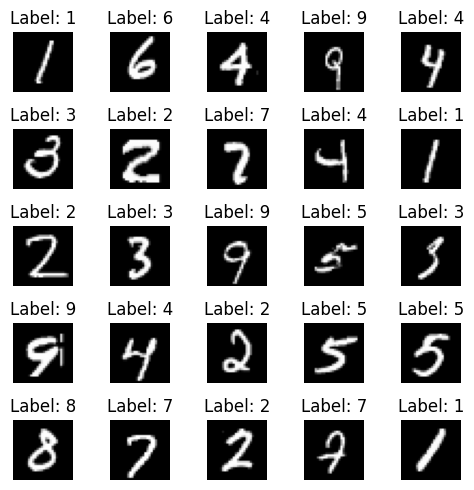

In [19]:
fig, axes = plt.subplots(5, 5, figsize=(5, 5))
axes = axes.ravel()
for i in range(25):
    axes[i].imshow(sampled_images[i], cmap='gray')
    axes[i].set_title(f'Label: {sampled_labels[i]}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [23]:
num_labels = len(np.unique(y_train))
print(f"Number of labels in the MNIST dataset: {num_labels}")

Number of labels in the MNIST dataset: 10


In [24]:
y_train_one_hot = keras.utils.to_categorical(y_train, num_classes=num_labels)
y_test_one_hot = keras.utils.to_categorical(y_test, num_classes=num_labels)

print("Shape of one-hot encoded training labels:", y_train_one_hot.shape)
print("Shape of one-hot encoded testing labels:", y_test_one_hot.shape)

Shape of one-hot encoded training labels: (60000, 10)
Shape of one-hot encoded testing labels: (10000, 10)


In [25]:
image_rows, image_cols = x_train.shape[1], x_train.shape[2]
print(f"Image dimensions: {image_rows}x{image_cols}")

Image dimensions: 28x28


In [26]:
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

print("Min pixel value after normalization:", x_train_normalized.min())
print("Max pixel value after normalization:", x_train_normalized.max())

Min pixel value after normalization: 0.0
Max pixel value after normalization: 1.0


In [27]:
model = keras.Sequential([
    keras.layers.InputLayer(input_shape=(image_rows * image_cols,)),  # Input layer
    keras.layers.Dense(12, activation='relu'),  # First hidden layer
    keras.layers.Dense(12, activation='relu'),  # Second hidden layer
    keras.layers.Dense(num_labels, activation='softmax')  # Output layer
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │         9,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,706 (37.91 KB)

 Trainable params: 9,706 (37.91 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Task
Train a Keras sequential model with two hidden layers on the MNIST dataset, evaluate its performance, and display the accuracy as a percentage.

## Reshape input data

### Subtask:
Reshape the normalized training and testing images to match the input shape of the model.


In [33]:
x_train_reshaped = x_train_normalized.reshape(-1, image_rows * image_cols)
x_test_reshaped = x_test_normalized.reshape(-1, image_rows * image_cols)
print("Shape of reshaped training data:", x_train_reshaped.shape)
print("Shape of reshaped testing data:", x_test_reshaped.shape)

Shape of reshaped training data: (60000, 784)
Shape of reshaped testing data: (10000, 784)


## Train the model

### Subtask:
Fit the compiled model to the reshaped training data and one-hot encoded labels.


In [34]:
history = model.fit(x_train_reshaped, y_train_one_hot, epochs=150, batch_size=32, validation_split=0.2)

Epoch 1/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9527 - loss: 0.1569 - val_accuracy: 0.9454 - val_loss: 0.1950
Epoch 2/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9530 - loss: 0.1557 - val_accuracy: 0.9455 - val_loss: 0.1952
Epoch 3/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9563 - loss: 0.1496 - val_accuracy: 0.9475 - val_loss: 0.1935
Epoch 4/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9556 - loss: 0.1483 - val_accuracy: 0.9467 - val_loss: 0.1885
Epoch 5/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9570 - loss: 0.1435 - val_accuracy: 0.9460 - val_loss: 0.1911
Epoch 6/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9587 - loss: 0.1372 - val_accuracy: 0.9472 - val_loss: 0.1895
Epoch 7/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9597 - loss: 0.1360 - val_accuracy: 0.9479 - val_loss: 0.1877
Epoch 8/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9602 - loss: 0

## Evaluate the model

### Subtask:
Evaluate the trained model on the reshaped testing data and one-hot encoded labels.


In [35]:
test_loss, test_accuracy = model.evaluate(x_test_reshaped, y_test_one_hot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9357 - loss: 0.3154


#Solve overfitting using early stop

In [44]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [45]:
history = model.fit(x_train_reshaped, y_train_one_hot, epochs=150, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9838 - loss: 0.0532 - val_accuracy: 0.9415 - val_loss: 0.3149
Epoch 2/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9840 - loss: 0.0544 - val_accuracy: 0.9398 - val_loss: 0.3345
Epoch 3/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9825 - loss: 0.0570 - val_accuracy: 0.9417 - val_loss: 0.3215
Epoch 4/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9831 - loss: 0.0579 - val_accuracy: 0.9382 - val_loss: 0.3333
Epoch 5/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9838 - loss: 0.0516 - val_accuracy: 0.9377 - val_loss: 0.3389
Epoch 6/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9840 - loss: 0.0527 - val_accuracy: 0.9394 - val_loss: 0.3326
Epoch 7/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9836 - loss: 0.0547 - val_accuracy: 0.9385 - val_loss: 0.3481
Epoch 8/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9832 - loss: 0

In [46]:
test_loss, test_accuracy = model.evaluate(x_test_reshaped, y_test_one_hot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9383 - loss: 0.3291


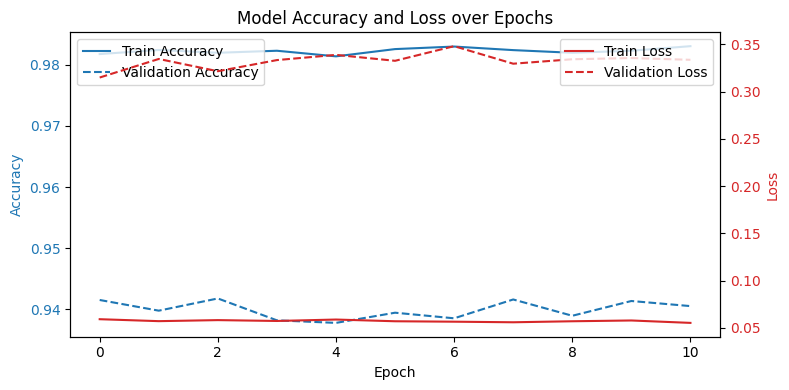

In [49]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot accuracy on the primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy', color=color)
ax1.plot(history.history['accuracy'], color=color, label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], color=color, linestyle='dashed', label='Validation Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

# Create a secondary y-axis for the loss
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Loss', color=color)
ax2.plot(history.history['loss'], color=color, label='Train Loss')
ax2.plot(history.history['val_loss'], color=color, linestyle='dashed', label='Validation Loss')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title('Model Accuracy and Loss over Epochs')
plt.tight_layout()
plt.show()